# Lab 3: Simple Linear Regression on Student Survey Data

This notebook demonstrates a complete end-to-end Machine Learning pipeline for Simple Linear Regression. 

### Objectives:
1. Load and clean raw survey data (handling missing values and outliers).
2. Perform Simple Linear Regression using `scikit-learn`.
3. Manually compute the regression parameters (slope and intercept) using Ordinary Least Squares (OLS) formulas.
4. Compare the coefficients, predictions, and evaluation metrics ($R^2$ and MSE) from both approaches.
5. Plot and visualize the data and regression line.
6. Save and reload the model parameters for future inference.

## Step 1: Ingesting Libraries and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import json

# Set aesthetic style for plotting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "sans-serif"

In [2]:
# Load the raw survey dataset
raw_df = pd.read_csv('student_survey_raw.csv')

print("=== Raw Dataset Inspection ===")
print(f"Shape: {raw_df.shape}")
print("\nFirst 5 rows:")
print(raw_df.head())

print("\nMissing values per column:")
print(raw_df.isnull().sum())

print("\nDescriptive statistics of raw data:")
print(raw_df.describe())

=== Raw Dataset Inspection ===
Shape: (120, 4)

First 5 rows:
  Student_ID  Study_Hours  Screen_Time_Hours  Exam_Score
0     STU001    17.483571           3.194857   71.627983
1     STU002    14.308678           1.392282   57.841543
2     STU003    18.238443           1.126754   75.735751
3     STU004    22.615149           5.813242   74.145924
4     STU005    13.829233           5.179901   62.771741

Missing values per column:
Student_ID           0
Study_Hours          6
Screen_Time_Hours    0
Exam_Score           6
dtype: int64

Descriptive statistics of raw data:
       Study_Hours  Screen_Time_Hours  Exam_Score
count   114.000000         120.000000  114.000000
mean     23.025857           3.466160   61.133634
std      92.351536           1.488071   15.312881
min      -5.000000           1.054188  -50.000000
25%      11.830003           2.248075   56.300636
50%      14.730410           3.465090   62.008020
75%      16.984813           4.756235   68.807374
max     999.000000        

## Step 2: Data Preprocessing and Cleaning

To clean the dataset, we will:
1. Drop rows with missing values (`NaN`) in our variables of interest (`Study_Hours` and `Exam_Score`).
2. Identify and filter out extreme outliers. For realistic student study hours, study hours per week should be between 0 and 60 hours. Exam scores must lie within $[0, 100]$.

In [3]:
# 1. Drop missing values in the variables we want to model
clean_df = raw_df.dropna(subset=['Study_Hours', 'Exam_Score']).copy()
print(f"Shape after dropping NaNs: {clean_df.shape}")

# 2. Filter outliers
# Study hours per week should realistically be between 0 and 60 hours
# Exam score should be between 0 and 100
clean_df = clean_df[
    (clean_df['Study_Hours'] >= 0) & 
    (clean_df['Study_Hours'] <= 60) & 
    (clean_df['Exam_Score'] >= 0) & 
    (clean_df['Exam_Score'] <= 100)
]

print(f"Shape after filtering outliers: {clean_df.shape}")
print("\nSummary statistics of clean dataset:")
print(clean_df.describe())

# Save clean dataset
clean_df.to_csv('student_survey_clean.csv', index=False)

Shape after dropping NaNs: (108, 4)
Shape after filtering outliers: (105, 4)

Summary statistics of clean dataset:
       Study_Hours  Screen_Time_Hours  Exam_Score
count   105.000000         105.000000  105.000000
mean     14.393276           3.480831   61.922773
std       4.623567           1.536402   11.131453
min       2.000000           1.054188   35.092724
25%      11.996807           1.978956   56.405130
50%      14.627770           3.472102   62.771741
75%      16.785563           4.789231   68.852697
max      27.316211           5.952526   87.489262


Let's visualize the distribution of `Study_Hours` and `Exam_Score` to ensure no major anomalies remain.

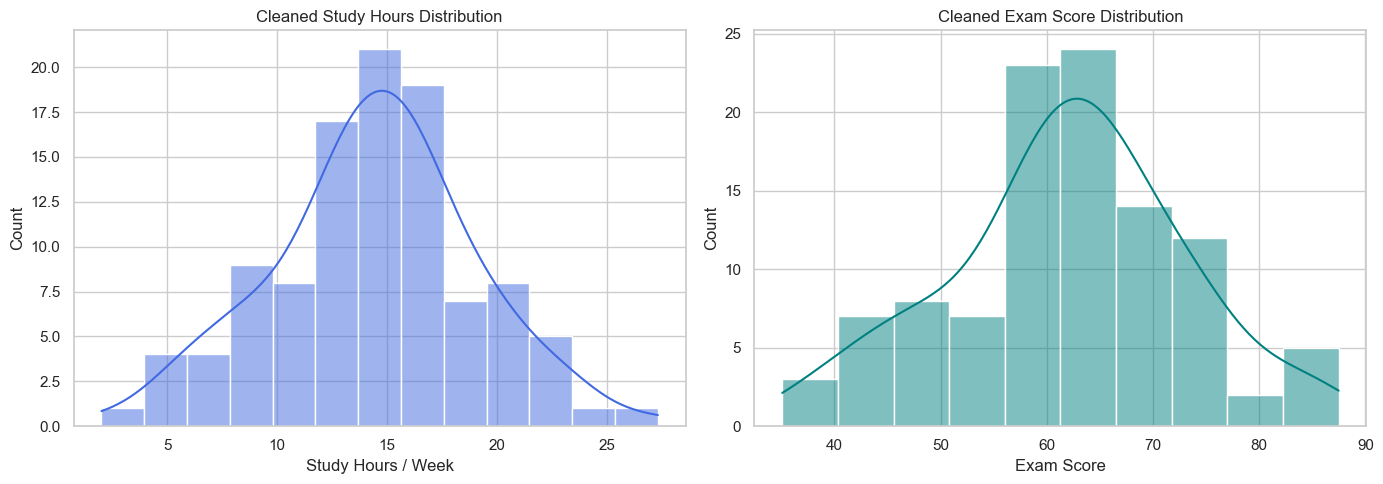

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(clean_df['Study_Hours'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Cleaned Study Hours Distribution')
axes[0].set_xlabel('Study Hours / Week')

sns.histplot(clean_df['Exam_Score'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Cleaned Exam Score Distribution')
axes[1].set_xlabel('Exam Score')

plt.tight_layout()
plt.show()

## Step 3: Simple Linear Regression using Scikit-Learn

Now we perform Simple Linear Regression with `Study_Hours` as our independent predictor variable ($X$) and `Exam_Score` as our dependent target variable ($Y$).

In [5]:
# Format variables for scikit-learn (X needs to be 2D)
X = clean_df[['Study_Hours']].values
y = clean_df['Exam_Score'].values

# Initialize and fit model
sk_model = LinearRegression()
sk_model.fit(X, y)

# Extract parameters
beta_1_sklearn = sk_model.coef_[0]
beta_0_sklearn = sk_model.intercept_

print("=== Scikit-Learn Model Parameters ===")
print(f"Intercept (beta_0): {beta_0_sklearn:.6f}")
print(f"Slope/Coefficient (beta_1): {beta_1_sklearn:.6f}")

# Compute predictions and metrics
y_pred_sklearn = sk_model.predict(X)
mse_sklearn = mean_squared_error(y, y_pred_sklearn)
r2_sklearn = r2_score(y, y_pred_sklearn)

print(f"Mean Squared Error (MSE): {mse_sklearn:.6f}")
print(f"R-squared (R^2): {r2_sklearn:.6f}")

=== Scikit-Learn Model Parameters ===
Intercept (beta_0): 29.417971
Slope/Coefficient (beta_1): 2.258332
Mean Squared Error (MSE): 14.741494
R-squared (R^2): 0.879886


## Step 4: Simple Linear Regression using Manual OLS Formulas

The Ordinary Least Squares (OLS) formulas to calculate the parameters for the best-fit line $y = eta_0 + eta_1 x$ are:

1. **Slope ($eta_1$):**
   $$\beta_1 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$

2. **Intercept ($eta_0$):**
   $$\beta_0 = \bar{y} - \beta_1 \bar{x}$$

where:
- $x_i$ and $y_i$ are the individual data points for `Study_Hours` and `Exam_Score` respectively.
- $\bar{x}$ and $\bar{y}$ are the mean values of $X$ and $Y$ respectively.
- $n$ is the number of samples.

In [6]:
# Flatten X for simpler manual computation
x_manual = clean_df['Study_Hours'].values
y_manual = clean_df['Exam_Score'].values

# 1. Calculate means
mean_x = np.mean(x_manual)
mean_y = np.mean(y_manual)

# 2. Calculate terms for beta_1
numerator = np.sum((x_manual - mean_x) * (y_manual - mean_y))
denominator = np.sum((x_manual - mean_x) ** 2)

# 3. Compute coefficients
beta_1_manual = numerator / denominator
beta_0_manual = mean_y - beta_1_manual * mean_x

print("=== Manual OLS Model Parameters ===")
print(f"Intercept (beta_0): {beta_0_manual:.6f}")
print(f"Slope/Coefficient (beta_1): {beta_1_manual:.6f}")

# 4. Calculate manual predictions and evaluation metrics
y_pred_manual = beta_0_manual + beta_1_manual * x_manual
n = len(y_manual)

# Mean Squared Error (MSE)
mse_manual = np.sum((y_manual - y_pred_manual) ** 2) / n

# Total Sum of Squares (TSS) and Residual Sum of Squares (RSS)
tss = np.sum((y_manual - mean_y) ** 2)
rss = np.sum((y_manual - y_pred_manual) ** 2)

# R-squared (R^2)
r2_manual = 1 - (rss / tss)

print(f"Mean Squared Error (MSE): {mse_manual:.6f}")
print(f"R-squared (R^2): {r2_manual:.6f}")

=== Manual OLS Model Parameters ===
Intercept (beta_0): 29.417971
Slope/Coefficient (beta_1): 2.258332
Mean Squared Error (MSE): 14.741494
R-squared (R^2): 0.879886


## Step 5: Comparing and Verifying Both Approaches

Let's compare the parameters and metrics side-by-side and assert their mathematical equivalence.

In [7]:
comparison_df = pd.DataFrame({
    'Parameter/Metric': ['Intercept (beta_0)', 'Slope (beta_1)', 'MSE', 'R-squared'],
    'Scikit-Learn': [beta_0_sklearn, beta_1_sklearn, mse_sklearn, r2_sklearn],
    'Manual OLS': [beta_0_manual, beta_1_manual, mse_manual, r2_manual]
})
comparison_df['Difference'] = np.abs(comparison_df['Scikit-Learn'] - comparison_df['Manual OLS'])
print("=== Method Comparison Table ===")
print(comparison_df.to_string(index=False))

# Numerical check using assertion (up to 10 decimal places)
np.testing.assert_almost_equal(beta_0_sklearn, beta_0_manual, decimal=10)
np.testing.assert_almost_equal(beta_1_sklearn, beta_1_manual, decimal=10)
np.testing.assert_almost_equal(mse_sklearn, mse_manual, decimal=10)
np.testing.assert_almost_equal(r2_sklearn, r2_manual, decimal=10)

print("\nVerification Successful! Scikit-learn and manual OLS formulas yield identical results.")

=== Method Comparison Table ===
  Parameter/Metric  Scikit-Learn  Manual OLS  Difference
Intercept (beta_0)     29.417971   29.417971         0.0
    Slope (beta_1)      2.258332    2.258332         0.0
               MSE     14.741494   14.741494         0.0
         R-squared      0.879886    0.879886         0.0

Verification Successful! Scikit-learn and manual OLS formulas yield identical results.


## Step 6: Visualizing the Best Fit Regression Line

We will draw a scatter plot of the cleaned data points along with the fitted regression line, shading the distance (residuals) between some actual values and predicted values to visualize the meaning of Ordinary Least Squares.

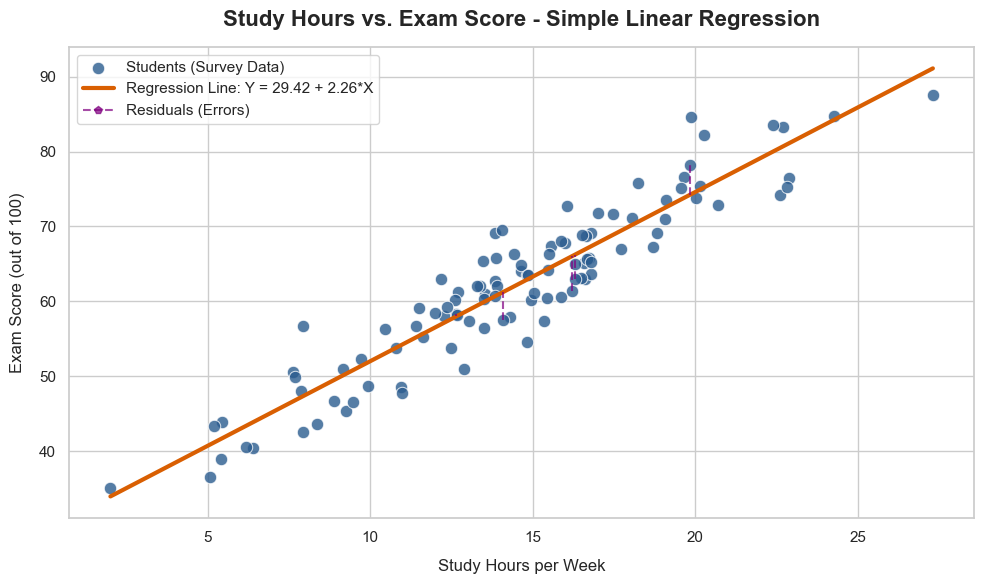

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=clean_df['Study_Hours'], y=clean_df['Exam_Score'], color='#2b5c8f', s=80, alpha=0.8, label='Students (Survey Data)')

# Plotting regression line
x_line = np.linspace(clean_df['Study_Hours'].min(), clean_df['Study_Hours'].max(), 100)
y_line = beta_0_sklearn + beta_1_sklearn * x_line
plt.plot(x_line, y_line, color='#d95f02', linewidth=3, label=f'Regression Line: Y = {beta_0_sklearn:.2f} + {beta_1_sklearn:.2f}*X')

# Visualizing residual lines for 5 random samples
np.random.seed(15)
sample_indices = np.random.choice(clean_df.index, size=5, replace=False)
for idx in sample_indices:
    xi = clean_df.loc[idx, 'Study_Hours']
    yi = clean_df.loc[idx, 'Exam_Score']
    yp = beta_0_sklearn + beta_1_sklearn * xi
    plt.vlines(xi, ymin=min(yi, yp), ymax=max(yi, yp), colors='purple', linestyles='dashed', alpha=0.7)
plt.plot([], [], 'p--', color='purple', alpha=0.7, label='Residuals (Errors)')

plt.title('Study Hours vs. Exam Score - Simple Linear Regression', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Study Hours per Week', fontsize=12, labelpad=10)
plt.ylabel('Exam Score (out of 100)', fontsize=12, labelpad=10)
plt.legend(loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()

# Save figure
plt.savefig('regression_plot.png', dpi=300)
plt.show()

## Step 7: Persisting Model Parameters and Verification

We will save:
1. The `scikit-learn` model object using `joblib`.
2. The manual parameters $\beta_0$ and $\beta_1$ as a JSON config file.

In [9]:
# 1. Save Scikit-Learn model
joblib.dump(sk_model, 'student_model.joblib')
print("Scikit-learn model successfully saved to 'student_model.joblib'")

# 2. Save manual coefficients to JSON
params = {
    'model_name': 'Simple Linear Regression - Student Survey Study Hours vs Exam Score',
    'intercept_beta_0': float(beta_0_manual),
    'slope_beta_1': float(beta_1_manual),
    'metrics': {
        'mse': float(mse_manual),
        'r2': float(r2_manual)
    }
}

with open('model_parameters.json', 'w') as f:
    json.dump(params, f, indent=4)
print("Model parameters successfully saved to 'model_parameters.json'")

Scikit-learn model successfully saved to 'student_model.joblib'
Model parameters successfully saved to 'model_parameters.json'


### Reloading and Testing Inference

Let's test both saved models on a student who studies 18.5 hours per week.

In [10]:
test_hours = 18.5

# 1. Scikit-learn reload & predict
loaded_sk_model = joblib.load('student_model.joblib')
pred_sk = loaded_sk_model.predict([[test_hours]])[0]

# 2. Manual JSON parameters reload & predict
with open('model_parameters.json', 'r') as f:
    loaded_params = json.load(f)

b0 = loaded_params['intercept_beta_0']
b1 = loaded_params['slope_beta_1']
pred_manual = b0 + b1 * test_hours

print(f"Inference comparison for {test_hours} study hours:")
print(f"-> Scikit-learn model prediction: {pred_sk:.4f}%")
print(f"-> Manual parameter prediction:     {pred_manual:.4f}%")
print(f"Difference: {abs(pred_sk - pred_manual):.12f}")

Inference comparison for 18.5 study hours:
-> Scikit-learn model prediction: 71.1971%
-> Manual parameter prediction:     71.1971%
Difference: 0.000000000000
